# California Housing Price Prediction using Linear Regression

## AI & ML Task 1

### Objective
The objective of this project is to build and evaluate a Linear Regression model for predicting house prices using the California Housing dataset.

### Tools & Libraries Used
- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Importing Required Libraries

In this section, we import all necessary libraries for:
- Data handling
- Data visualization
- Model training
- Model evaluation

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## 2. Loading the Dataset

The California Housing dataset is a popular machine learning dataset containing information about housing districts in California.

Target Variable:
- MedHouseVal (Median House Value)

In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("MedHouseVal")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Dataset Overview

Before training the model, it is important to understand:
- Number of rows and columns
- Feature names
- Data types
- Missing values

In [3]:
df.shape

(20640, 9)

In [4]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Observation

The dataset contains 20,640 records and 9 columns.
All features are numerical and suitable for Linear Regression.

## 4. Missing Value Analysis

Checking whether any feature contains missing values.

In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Observation

No missing values were found in the dataset.
Therefore, no imputation or cleaning was required.

## 5. Statistical Summary

The describe() function provides:
- Mean
- Standard Deviation
- Minimum Value
- Maximum Value
- Quartiles

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Observation

The dataset shows variation across all features.
Some features have larger ranges than others, indicating different scales.

## 6. Correlation Analysis

A correlation heatmap helps identify relationships between variables.

Values close to:
- +1 indicate strong positive correlation
- -1 indicate strong negative correlation
- 0 indicate weak correlation

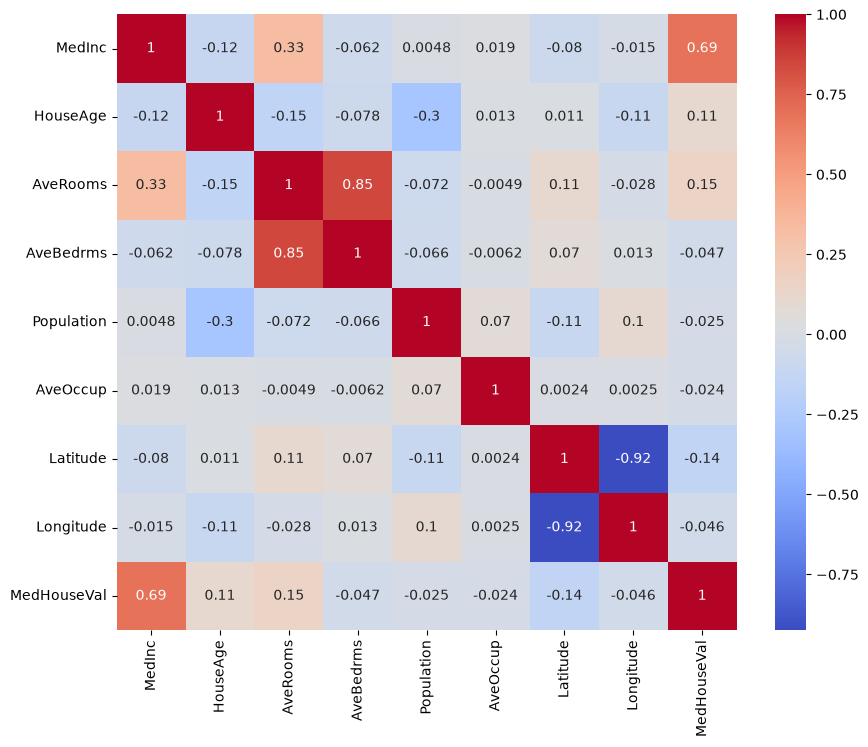

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Observation

Median Income (MedInc) shows one of the strongest positive correlations with house value.

Geographical features such as Latitude and Longitude also influence house prices.

## 7. Distribution of Target Variable

Understanding the distribution of the target variable helps identify skewness and outliers.

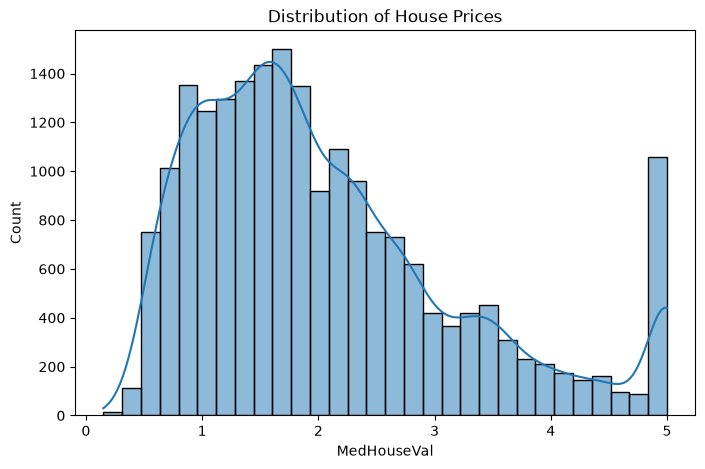

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MedHouseVal"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")

plt.show()

### Observation

The target variable is slightly right-skewed, indicating that a smaller number of houses have very high prices.

## 8. Feature and Target Selection

Separating:
- Input Features (X)
- Target Variable (y)

In [10]:
X = df.drop(columns=["MedHouseVal"])

y = df["MedHouseVal"]

## 9. Train-Test Split

The dataset is split into:
- 80% Training Data
- 20% Testing Data

This allows us to evaluate model performance on unseen data.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


## 10. Model Training

Linear Regression is trained using the training dataset.

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


## 11. Model Prediction

The trained model is used to predict house prices on the testing dataset.

In [14]:
y_pred = model.predict(X_test)

## 12. Model Evaluation

Performance is measured using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

In [15]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 0.5332001304956555
RMSE: 0.7455813830127763
R2 : 0.575787706032451


### Observation

The model achieved:

- MAE = 0.5332001304956555
- RMSE = 0.7455813830127763
- R² = 0.575787706032451

The R² score indicates how much variance in house prices is explained by the model.

## 13. Actual vs Predicted Visualization

This plot compares actual house prices with model predictions.

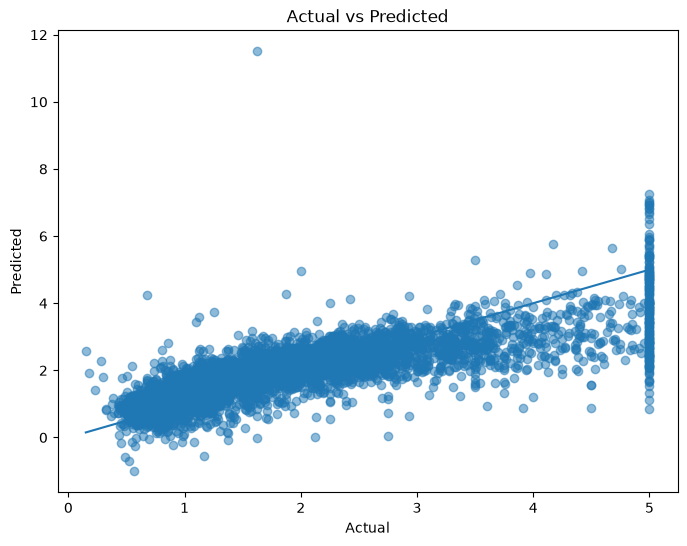

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

### Observation

Points closer to the diagonal line indicate more accurate predictions.

## 14. Residual Analysis

Residuals represent the difference between actual and predicted values.

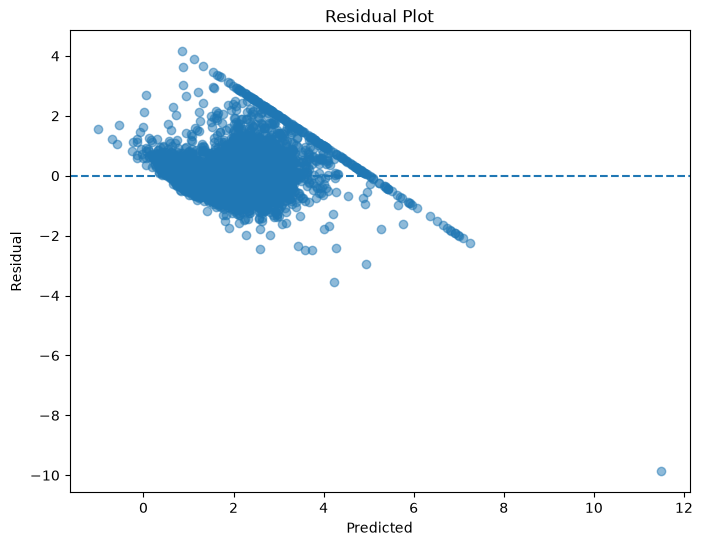

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

### Observation

Residuals are distributed around zero, indicating that the model does not show a strong systematic bias.

## 15. Feature Coefficients

Linear Regression coefficients indicate how strongly each feature influences house prices.

In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


## 16. Saving the Model

The trained model is saved as a pickle (.pkl) file for future use.

In [19]:
import joblib

joblib.dump(
    model,
    "california_house_model.pkl"
)

['california_house_model.pkl']

# Conclusion

A Linear Regression model was successfully built and evaluated using the California Housing dataset.

Key Findings:
- No missing values were present.
- Median Income showed strong influence on house value.
- The model achieved reasonable prediction performance.
- Linear Regression serves as a strong baseline model.

Future Improvements:
- Feature Engineering
- Outlier Handling
- Random Forest Regression
- XGBoost
- Hyperparameter Tuning